# Heart Disease Classification (UCI Multi-Site Dataset)

**Goal:** Build a classification model that predicts heart disease severity (`num`, 0-4) from patient clinical measurements.

**Dataset:** 920 patients from 4 sites (Cleveland, Hungary, Switzerland, VA Long Beach).

**Steps:**
1. Load and explore the dataset
2. Clean and preprocess (handle missing values, encode categories)
3. Split into training and testing sets
4. Train and compare multiple classification algorithms
5. Evaluate and pick the best model

## 1. Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv("heart_disease_uci.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 920 rows, 16 columns


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [3]:
# Column meanings:
# age      - age in years
# sex      - Male / Female
# dataset  - site the data was collected from
# cp       - chest pain type
# trestbps - resting blood pressure (mm Hg)
# chol     - serum cholesterol (mg/dl)
# fbs      - fasting blood sugar > 120 mg/dl (True/False)
# restecg  - resting electrocardiographic results
# thalch   - maximum heart rate achieved
# exang    - exercise-induced angina (True/False)
# oldpeak  - ST depression induced by exercise
# slope    - slope of the peak exercise ST segment
# ca       - number of major vessels colored by fluoroscopy
# thal     - thalassemia test result
# num      - target: 0 = no disease, 1-4 = increasing severity

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


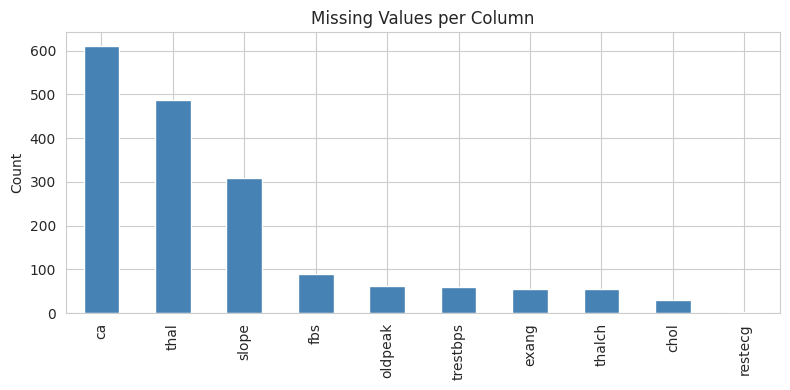

In [4]:
# Missing values per column
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='steelblue')
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


/tmp/ipykernel_594/89376028.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=df, palette='viridis')


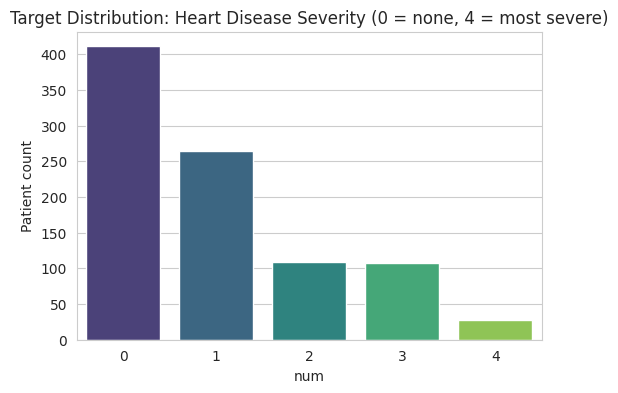

In [5]:
# Target class distribution (multi-class: 0-4)
print(df['num'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x='num', data=df, palette='viridis')
plt.title("Target Distribution: Heart Disease Severity (0 = none, 4 = most severe)")
plt.xlabel("num")
plt.ylabel("Patient count")
plt.show()

/tmp/ipykernel_594/4243105352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dataset', data=df, palette='mako')


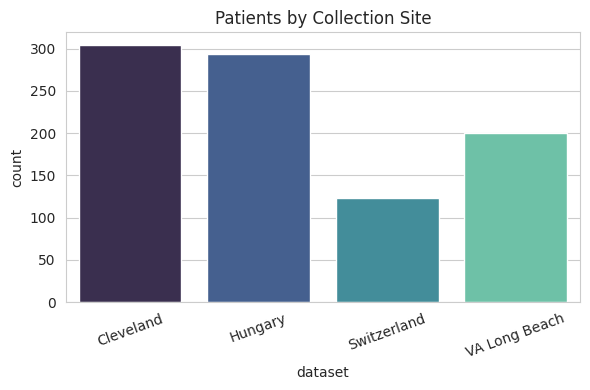

In [6]:
# Patients by collection site
plt.figure(figsize=(6, 4))
sns.countplot(x='dataset', data=df, palette='mako')
plt.title("Patients by Collection Site")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

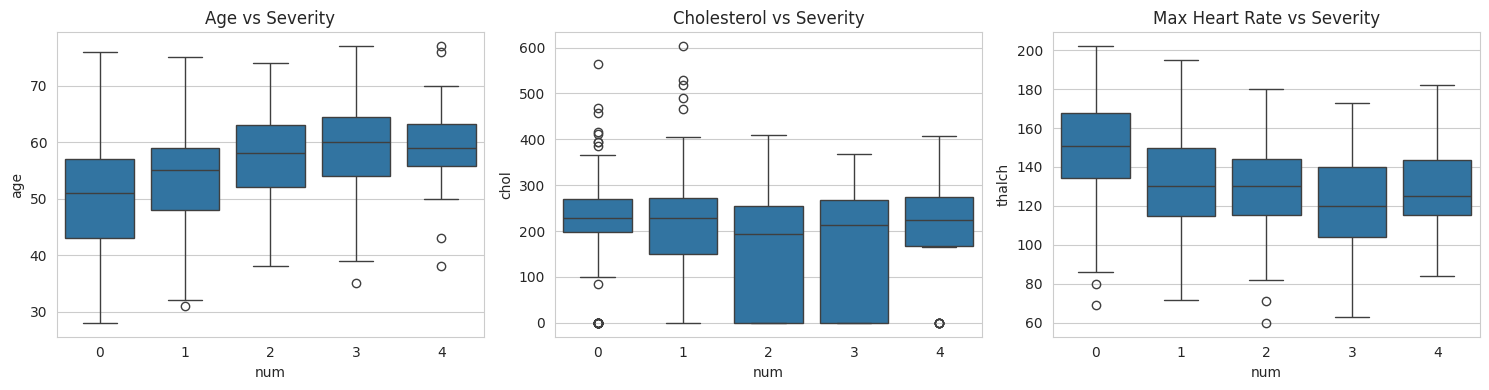

In [7]:
# How a few key features relate to disease severity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x='num', y='age', data=df, ax=axes[0])
axes[0].set_title('Age vs Severity')
sns.boxplot(x='num', y='chol', data=df, ax=axes[1])
axes[1].set_title('Cholesterol vs Severity')
sns.boxplot(x='num', y='thalch', data=df, ax=axes[2])
axes[2].set_title('Max Heart Rate vs Severity')
plt.tight_layout()
plt.show()

## 2. Clean and Preprocess the Data

This dataset has real-world messiness: missing values in several columns, and a mix of numeric and categorical (text/boolean) features. We'll:
- Drop the `id` column (not predictive) and `dataset` (site label, not a clinical feature)
- Separate numeric vs categorical columns
- Build a preprocessing pipeline that imputes missing values and encodes categories
- Let the pipeline handle this consistently for every model, avoiding data leakage

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Drop non-predictive columns
model_df = df.drop(columns=['id', 'dataset'])

X = model_df.drop(columns=['num'])
y = model_df['num']

numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [9]:
# Preprocessing pipeline: impute missing values, then scale numeric / one-hot encode categorical
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

## 3. Split Data into Training and Testing Sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keep the same severity-level proportions in both sets
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

Training set: 736 samples
Testing set:  184 samples

Training set class balance:
num
0    0.447
1    0.288
2    0.118
3    0.117
4    0.030
Name: proportion, dtype: float64


## 4. Train and Compare Multiple Classification Algorithms

We'll compare three common, simple classifiers:
- **Logistic Regression** — a linear baseline
- **Decision Tree** — captures non-linear rules, easy to interpret
- **Random Forest** — an ensemble of trees, usually more accurate and robust

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "pipeline": pipeline,
        "predictions": y_pred,
        "accuracy": acc
    }
    print(f"{name}: accuracy = {acc:.2%}")

Logistic Regression: accuracy = 57.61%
Decision Tree: accuracy = 51.63%


Random Forest: accuracy = 56.52%


## 5. Evaluate and Compare the Models

              Model  Accuracy
Logistic Regression  0.576087
      Random Forest  0.565217
      Decision Tree  0.516304


/tmp/ipykernel_594/179603023.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=acc_df, palette="crest")


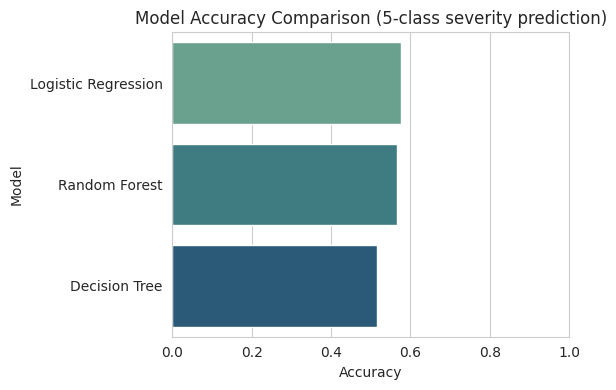

In [12]:
# Side-by-side accuracy comparison
acc_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["accuracy"] for m in results]
}).sort_values("Accuracy", ascending=False)

print(acc_df.to_string(index=False))

plt.figure(figsize=(6, 4))
sns.barplot(x="Accuracy", y="Model", data=acc_df, palette="crest")
plt.xlim(0, 1)
plt.title("Model Accuracy Comparison (5-class severity prediction)")
plt.tight_layout()
plt.show()

In [13]:
# Detailed classification report for each model
for name in results:
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, results[name]["predictions"], zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.84      0.80        82
           1       0.48      0.57      0.52        53
           2       0.30      0.14      0.19        22
           3       0.20      0.19      0.20        21
           4       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.35      0.35      0.34       184
weighted avg       0.54      0.58      0.55       184


Decision Tree
              precision    recall  f1-score   support

           0       0.71      0.84      0.77        82
           1       0.43      0.36      0.39        53
           2       0.14      0.14      0.14        22
           3       0.18      0.19      0.19        21
           4       0.00      0.00      0.00         6

    accuracy                           0.52       184
   macro avg       0.29      0.31      0.30       184
weighted avg       0.48      0.52      0.

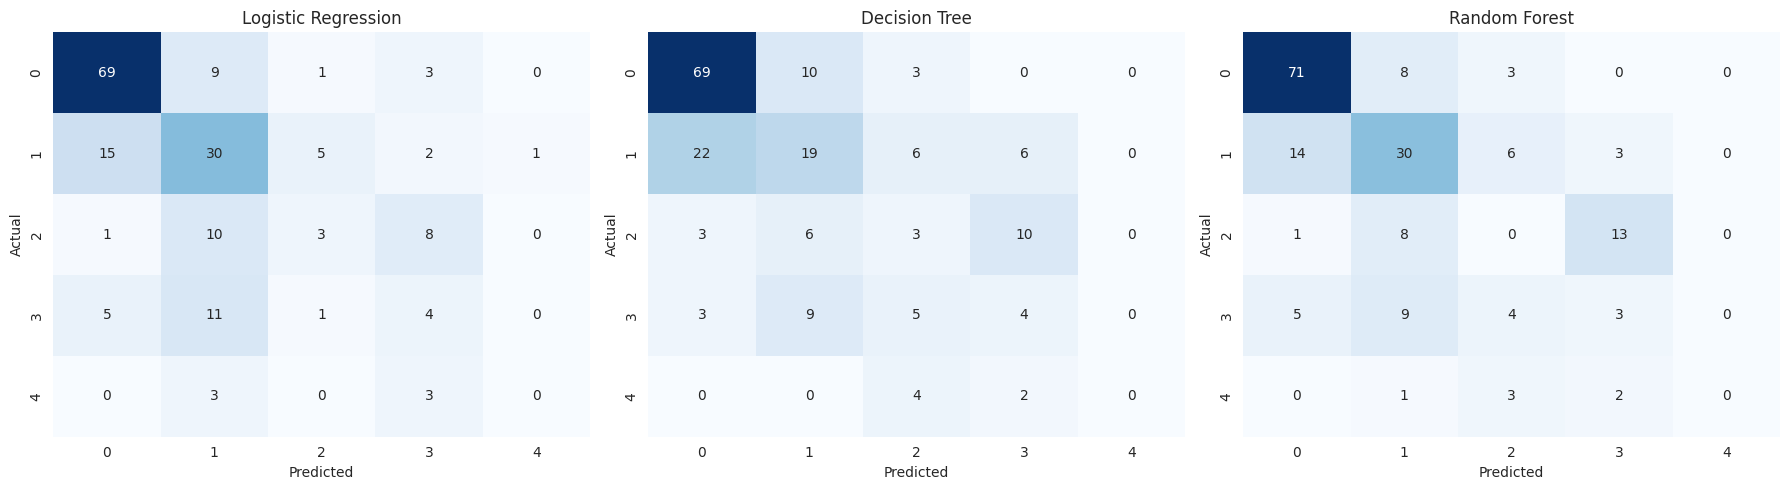

In [14]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, results):
    cm = confusion_matrix(y_test, results[name]["predictions"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

/tmp/ipykernel_594/467815886.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=importance_df, palette="flare")


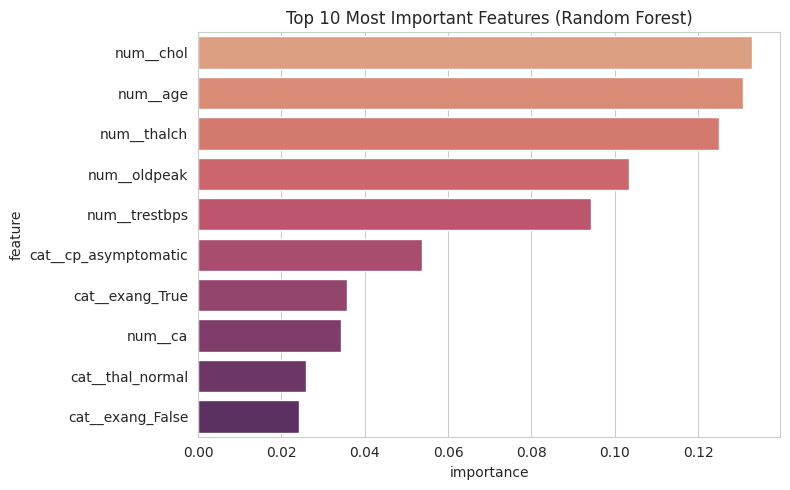

In [15]:
# Feature importance from the Random Forest (most interpretable for this purpose)
rf_pipeline = results["Random Forest"]["pipeline"]
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=importance_df, palette="flare")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.tight_layout()
plt.show()

## 6. Conclusion

- We trained and compared **Logistic Regression**, **Decision Tree**, and **Random Forest** on the full 5-class severity target (`num` = 0 to 4).
- Multi-class severity prediction is harder than binary disease/no-disease prediction — accuracy and per-class recall (especially for rarer severity levels 3-4) will be lower than a binary setup.
- The bar chart and confusion matrices above show which model generalizes best and where each model tends to make mistakes (commonly confusing adjacent severity levels, e.g. 1 vs 2).
- The feature importance plot highlights which clinical measurements are most predictive of heart disease severity according to the Random Forest.

**Possible next steps:** try class-balancing techniques (e.g. `class_weight='balanced'`), tune hyperparameters with cross-validation, or collapse `num` into binary (0 vs 1-4) if higher accuracy is more important than capturing severity detail.